## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

Created by ANH TRAN (015621450)  
Last updated: 3/18/26

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [12]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
alc_cons = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
alc_cons

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [13]:
alc_cons.drop(columns=['total_litres_of_pure_alcohol'], inplace=True)
tidy_alc = alc_cons.melt(
    id_vars="country",
    var_name="drink",
    value_name="servings"
)
tidy_alc

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [14]:
def extract_drink(word):
    split_word = word.split("_")
    return split_word[0]

tidy_alc['drink'] = tidy_alc['drink'].map(extract_drink)
tidy_alc

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217
...,...,...,...
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4


#### Categorical Plot 1

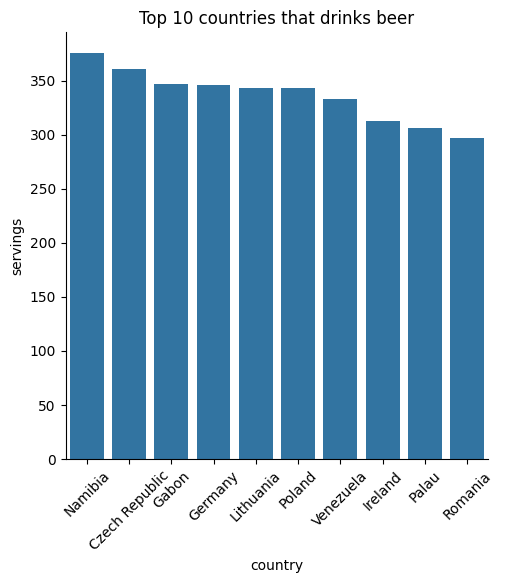

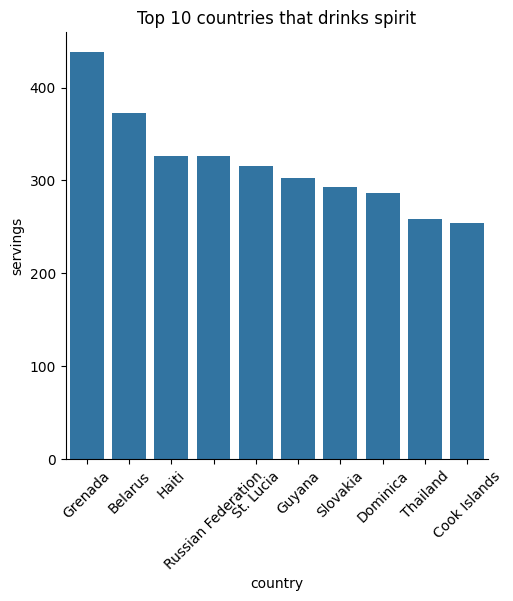

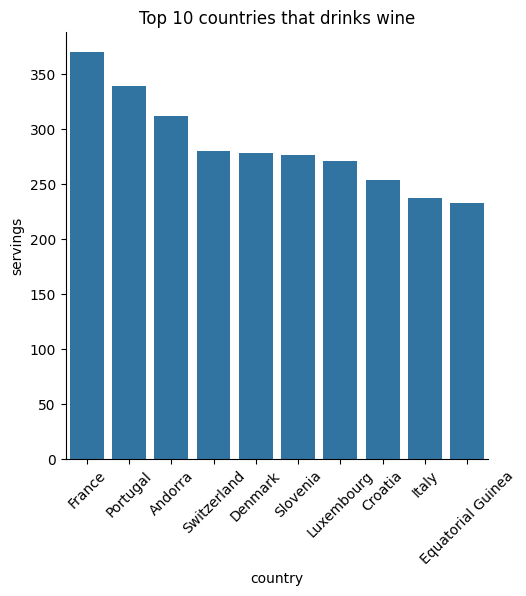

In [19]:
drink_type = tidy_alc['drink'].unique()

for drinks in drink_type:
    top_10_drinks = tidy_alc[tidy_alc['drink'] == drinks].nlargest(n=10,columns=['servings'])
    sns.catplot(data=top_10_drinks, x = "country", y = "servings", kind="bar")
    plt.xticks(rotation=45)
    plt.title(f"Top 10 countries that drinks {drinks}")


Based on the three categorical plots for each type of drink, we can see the top 10 countries that drink the most for each drink type. However, the first country that drink the most beer is Namibia, Grenada drinks the most spirit, and France drinks the most wine.

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

NOTE: I tried two ways to make a wide dataframe with pivot table, where the first dataframe has 3 rows but 193 columns with country as the column and drink as the index. The second wide dataframe has 193 rows and 3 columns, where country is not the index and drink is not the column. Both has servings as the value.

In [30]:
wide_alc_drink_index = pd.pivot_table(tidy_alc,columns="country", values="servings", index='drink')
wide_alc_drink_index

country,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua & Barbuda,Argentina,Armenia,Australia,Austria,...,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
drink,,,,,,,,,,,,,,,,,,,,,
beer,0.0,89.0,25.0,245.0,217.0,102.0,193.0,21.0,261.0,279.0,...,16.0,219.0,115.0,25.0,21.0,333.0,111.0,6.0,32.0,64.0
spirit,0.0,132.0,0.0,138.0,57.0,128.0,25.0,179.0,72.0,75.0,...,135.0,126.0,35.0,101.0,18.0,100.0,2.0,0.0,19.0,18.0
wine,0.0,54.0,14.0,312.0,45.0,45.0,221.0,11.0,212.0,191.0,...,5.0,195.0,220.0,8.0,11.0,3.0,1.0,0.0,4.0,4.0


In [32]:
wide_alc_country_index = pd.pivot_table(tidy_alc, columns="drink", values="servings", index="country")
wide_alc_country_index


drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
...,...,...,...
Venezuela,333.0,100.0,3.0
Vietnam,111.0,2.0,1.0
Yemen,6.0,0.0,0.0
